# NBA Home Win Probability

Predict home-team win probability from pre-game information only.

**Data**: single supplied CSV of 2025-26 NBA games  
**Split**: Train (before March 2026) / Validation (March) / Hold-out (April)  
**Models**: Log5, Logistic Regression, Random Forest, XGBoost  
**Primary metrics**: Brier score, log-loss  

Core feature engineering and model definitions live in `win_probability.py` so the notebook stays readable and the heavy loop is only executed once on import / call.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    brier_score_loss, log_loss, accuracy_score, roc_auc_score
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression as LR_cal
import matplotlib.pyplot as plt

from win_probability import (
    build_features,
    FEATURE_SETS,
    MODELS,
    MODEL_SETS,
    RANDOM_STATE,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
np.random.seed(RANDOM_STATE)
print("win_probability imported successfully")
print("Feature regimes:", list(FEATURE_SETS.keys()))
print("Models:", list(MODELS.keys()))


win_probability imported successfully
Feature regimes: ['S0', 'S1', 'S2', 'S3']
Models: ['log5', 'logistic', 'rf', 'xgboost']


## 1. Load data

In [2]:
CSV_PATH = Path("nba-win-probability-data.csv")
df_raw = pd.read_csv(CSV_PATH)
df_raw["game_date"] = pd.to_datetime(df_raw["game_date"])
df_raw = df_raw.sort_values(["game_date", "game_id"]).reset_index(drop=True)

print(f"Games: {len(df_raw):,}")
print(f"Date range: {df_raw['game_date'].min().date()} → {df_raw['game_date'].max().date()}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


Games: 1,230
Date range: 2025-10-21 → 2026-04-12
Columns: ['game_id', 'game_date', 'away', 'away_wins', 'away_losses', 'away_points', 'away_turnovers', 'away_fouls', 'away_rebounds', 'home', 'home_wins', 'home_losses', 'home_points', 'home_turnovers', 'home_fouls', 'home_rebounds']


,game_id,game_date,away,away_wins,away_losses,away_points,away_turnovers,away_fouls,away_rebounds,home,home_wins,home_losses,home_points,home_turnovers,home_fouls,home_rebounds
0,22500001,2025-10-21,HOU,0,0,124,25,26,73,OKC,0,0,125,12,27,49
1,22500002,2025-10-21,GSW,0,0,119,19,27,41,LAL,0,0,109,20,21,49
2,22500003,2025-10-22,CLE,0,0,111,15,26,50,NYK,0,0,119,14,23,58


## 2. Construct pre-game features

All features use only information available before tip-off.  
Running team statistics are updated *after* the features for each game have been extracted, eliminating leakage.

Opponent box-score stats supply the complementary quantities:
- points allowed = opponent points
- rebounds allowed = opponent rebounds
- takeaways = opponent turnovers
- fouls drawn = opponent fouls

The heavy loop lives in `win_probability.build_features`.


In [3]:
df = build_features(df_raw)

print(f"Feature matrix shape: {df.shape}")
print(f"Home win rate: {df['home_win'].mean():.3f}")
df.head(3)


Feature matrix shape: (1230, 53)
Home win rate: 0.554


,game_id,game_date,home,away,home_win,home_win_pct_overall,away_win_pct_overall,home_win_pct_at_home,away_win_pct_on_road,home_points_overall,away_points_overall,home_points_at_home,away_points_on_road,home_points_allowed_overall,away_points_allowed_overall,home_points_allowed_at_home,away_points_allowed_on_road,home_rebounds_overall,away_rebounds_overall,home_rebounds_allowed_overall,away_rebounds_allowed_overall,home_rebounds_net_overall,away_rebounds_net_overall,home_rebounds_net_at_home,away_rebounds_net_on_road,home_turnovers_overall,away_turnovers_overall,home_takeaways_overall,away_takeaways_overall,home_turnovers_net_overall,away_turnovers_net_overall,home_turnovers_net_at_home,away_turnovers_net_on_road,home_fouls_overall,away_fouls_overall,home_fouls_drawn_overall,away_fouls_drawn_overall,home_fouls_net_overall,away_fouls_net_overall,home_fouls_net_at_home,away_fouls_net_on_road,home_games_played,away_games_played,home_rest_days,away_rest_days,points_overall_diff,points_allowed_overall_diff,rebounds_net_overall_diff,turnovers_net_overall_diff,fouls_net_overall_diff,rest_days_diff,games_played_diff,games_played_sum
0,22500001,2025-10-21,OKC,HOU,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,22500002,2025-10-21,LAL,GSW,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,22500003,2025-10-22,NYK,CLE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


## 3. Feature regimes

In [4]:
for name, feats in FEATURE_SETS.items():
    print(f"{name}: {len(feats)} features")


S0: 2 features
S1: 10 features
S2: 22 features
S3: 27 features


## 4. Chronological split

In [5]:
train = df[df["game_date"] < "2026-03-01"].copy()
val   = df[(df["game_date"] >= "2026-03-01") & (df["game_date"] < "2026-04-01")].copy()
hold  = df[df["game_date"] >= "2026-04-01"].copy()

print(f"Train:    {len(train):4d} games  ({train['game_date'].min().date()} → {train['game_date'].max().date()})")
print(f"Valid:    {len(val):4d} games  ({val['game_date'].min().date()} → {val['game_date'].max().date()})")
print(f"Hold-out: {len(hold):4d} games  ({hold['game_date'].min().date()} → {hold['game_date'].max().date()})")
print(f"\nHome-win rates  train={train['home_win'].mean():.3f}  val={val['home_win'].mean():.3f}  hold={hold['home_win'].mean():.3f}")


Train:     895 games  (2025-10-21 → 2026-02-28)
Valid:     239 games  (2026-03-01 → 2026-03-31)
Hold-out:   96 games  (2026-04-01 → 2026-04-12)

Home-win rates  train=0.537  val=0.603  hold=0.594


## 5. Train and evaluate

In [6]:
def get_xy(frame, features):
    X = frame[features].copy()
    y = frame["home_win"].values
    # median impute any residual early-season NaNs (still using only that split's data)
    X = X.fillna(X.median(numeric_only=True))
    return X, y

results = {}          # hold-out metrics
val_results = {}      # validation metrics
fitted = {}           # store models + hold-out predictions

for model_name, fsets in MODEL_SETS.items():
    for fset_name in fsets:
        feats = FEATURE_SETS[fset_name]
        key = f"{model_name}__{fset_name}"
        print(f">>> {key}  ({len(feats)} features)")

        X_tr, y_tr = get_xy(train, feats)
        X_va, y_va = get_xy(val, feats)
        X_ho, y_ho = get_xy(hold, feats)

        model = MODELS[model_name]()
        model.fit(X_tr, y_tr)

        proba_va = model.predict_proba(X_va)[:, 1]
        proba_ho = model.predict_proba(X_ho)[:, 1]

        def metrics(y, p):
            p = np.clip(p, 1e-6, 1-1e-6)
            return {
                "brier": brier_score_loss(y, p),
                "logloss": log_loss(y, p),
                "accuracy": accuracy_score(y, (p >= 0.5).astype(int)),
                "auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            }

        val_results[key] = metrics(y_va, proba_va)
        results[key] = metrics(y_ho, proba_ho)
        fitted[key] = {
            "model": model,
            "features": feats,
            "y_ho": y_ho,
            "proba_ho": proba_ho,
            "y_va": y_va,
            "proba_va": proba_va,
        }

        m = results[key]
        print(f"    hold-out  Brier={m['brier']:.4f}  logloss={m['logloss']:.4f}  "
              f"acc={m['accuracy']:.3f}  auc={m['auc']:.3f}")


>>> log5__S0  (2 features)
    hold-out  Brier=0.1697  logloss=0.5175  acc=0.750  auc=0.849
>>> logistic__S0  (2 features)
    hold-out  Brier=0.1890  logloss=0.5668  acc=0.823  auc=0.857
>>> logistic__S1  (10 features)
    hold-out  Brier=0.1942  logloss=0.5737  acc=0.708  auc=0.850
>>> logistic__S2  (22 features)
    hold-out  Brier=0.2003  logloss=0.5874  acc=0.740  auc=0.830
>>> logistic__S3  (27 features)
    hold-out  Brier=0.2020  logloss=0.5912  acc=0.708  auc=0.825
>>> rf__S0  (2 features)
    hold-out  Brier=0.1797  logloss=0.5431  acc=0.771  auc=0.842
>>> rf__S1  (10 features)
    hold-out  Brier=0.1661  logloss=0.5126  acc=0.792  auc=0.862
>>> rf__S2  (22 features)
    hold-out  Brier=0.1701  logloss=0.5226  acc=0.781  auc=0.855
>>> rf__S3  (27 features)
    hold-out  Brier=0.1718  logloss=0.5262  acc=0.802  auc=0.862
>>> xgboost__S0  (2 features)
    hold-out  Brier=0.2109  logloss=0.6062  acc=0.646  auc=0.717
>>> xgboost__S1  (10 features)
    hold-out  Brier=0.1871  logl

## 6. Hold-out comparison grids

In [7]:
rows = []
for key, m in results.items():
    model, fset = key.split("__")
    rows.append({"model": model, "feature_set": fset, **m})

res_df = pd.DataFrame(rows)

for metric in ["brier", "logloss", "accuracy"]:
    print("=" * 50)
    print(metric.upper())
    print(res_df.pivot(index="model", columns="feature_set", values=metric).round(4))
    print()


BRIER
feature_set      S0      S1      S2      S3
model                                      
log5         0.1697     NaN     NaN     NaN
logistic     0.1890  0.1942  0.2003  0.2020
rf           0.1797  0.1661  0.1701  0.1718
xgboost      0.2109  0.1871  0.1887  0.1796

LOGLOSS
feature_set      S0      S1      S2      S3
model                                      
log5         0.5175     NaN     NaN     NaN
logistic     0.5668  0.5737  0.5874  0.5912
rf           0.5431  0.5126  0.5226  0.5262
xgboost      0.6062  0.5628  0.5677  0.5363

ACCURACY
feature_set      S0      S1      S2      S3
model                                      
log5         0.7500     NaN     NaN     NaN
logistic     0.8229  0.7083  0.7396  0.7083
rf           0.7708  0.7917  0.7812  0.8021
xgboost      0.6458  0.7396  0.7292  0.7083



## 7. Finalists

We lock one regime per model family (best validation Brier, with a preference for simpler regimes when close):


In [8]:
FINALISTS = {
    "log5__S0":     "Log5–S0",
    "logistic__S0": "Logistic–S0",
    "rf__S1":       "RF–S1",
    "xgboost__S3":  "XGB–S3",
}

print("Locked finalists:")
for k, label in FINALISTS.items():
    m = results[k]
    print(f"  {label:12s}  Brier={m['brier']:.4f}  logloss={m['logloss']:.4f}  acc={m['accuracy']:.3f}")


Locked finalists:
  Log5–S0       Brier=0.1697  logloss=0.5175  acc=0.750
  Logistic–S0   Brier=0.1890  logloss=0.5668  acc=0.823
  RF–S1         Brier=0.1661  logloss=0.5126  acc=0.792
  XGB–S3        Brier=0.1796  logloss=0.5363  acc=0.708


## 8. Calibration diagnostics

Expected Calibration Error (ECE), Maximum Calibration Error (MCE), calibration slope & intercept.


In [9]:
def expected_calibration_error(y, p, n_bins=10, strategy="quantile"):
    y, p = np.asarray(y), np.asarray(p)
    if strategy == "quantile":
        bins = np.quantile(p, np.linspace(0, 1, n_bins + 1))
        bins = np.unique(bins)
    else:
        bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    for i in range(len(bins) - 1):
        mask = (p >= bins[i]) & (p < bins[i + 1] if i < len(bins) - 2 else p <= bins[i + 1])
        if mask.sum() == 0:
            continue
        conf = p[mask].mean()
        acc = y[mask].mean()
        gap = abs(acc - conf)
        ece += mask.mean() * gap
        mce = max(mce, gap)
    return ece, mce

def calibration_slope_intercept(y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LR_cal(penalty=None, solver="lbfgs", max_iter=1000)
    lr.fit(logit, y)
    return float(lr.coef_[0][0]), float(lr.intercept_[0])

cal_rows = []
for key, label in FINALISTS.items():
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    ece, mce = expected_calibration_error(y, p)
    slope, intercept = calibration_slope_intercept(y, p)
    cal_rows.append({
        "model": label,
        "ECE": ece,
        "MCE": mce,
        "slope": slope,
        "intercept": intercept,
        "Brier": results[key]["brier"],
        "logloss": results[key]["logloss"],
    })

cal_df = pd.DataFrame(cal_rows).set_index("model")
print(cal_df.round(4))
print()
print("Ideal: ECE/MCE ≈ 0, slope ≈ 1, intercept ≈ 0")


                ECE     MCE   slope  intercept   Brier  logloss
model                                                          
Log5–S0      0.1371  0.3379  1.7748     0.5503  0.1697   0.5175
Logistic–S0  0.2129  0.3028  3.6827    -0.0684  0.1890   0.5668
RF–S1        0.1613  0.3366  1.9712     0.4646  0.1661   0.5126
XGB–S3       0.1301  0.4324  1.0333     0.8132  0.1796   0.5363

Ideal: ECE/MCE ≈ 0, slope ≈ 1, intercept ≈ 0


## 9. Reliability diagrams (hold-out)

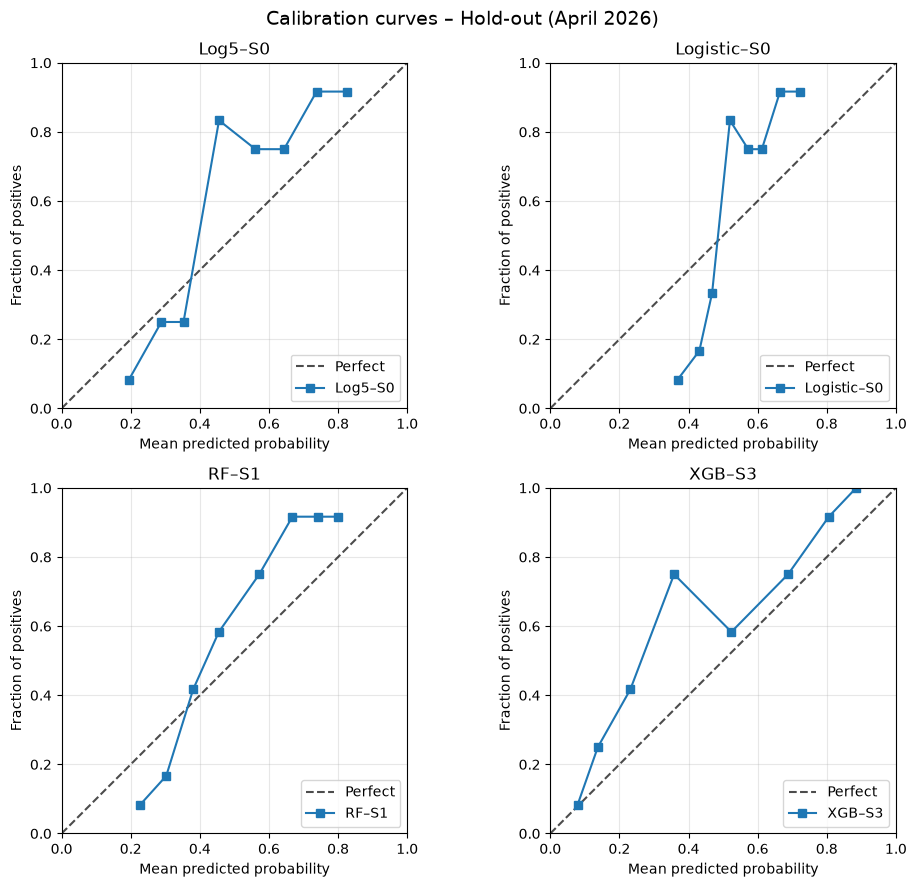

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, (key, label) in zip(axes, FINALISTS.items()):
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy="quantile")
    ax.plot([0, 1], [0, 1], "k--", label="Perfect", alpha=0.7)
    ax.plot(mean_pred, frac_pos, "s-", color="C0", label=label)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(label)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

fig.suptitle("Calibration curves – Hold-out (April 2026)", fontsize=14)
plt.tight_layout()
plt.show()


## 10. Overlay reliability + predicted-probability histograms

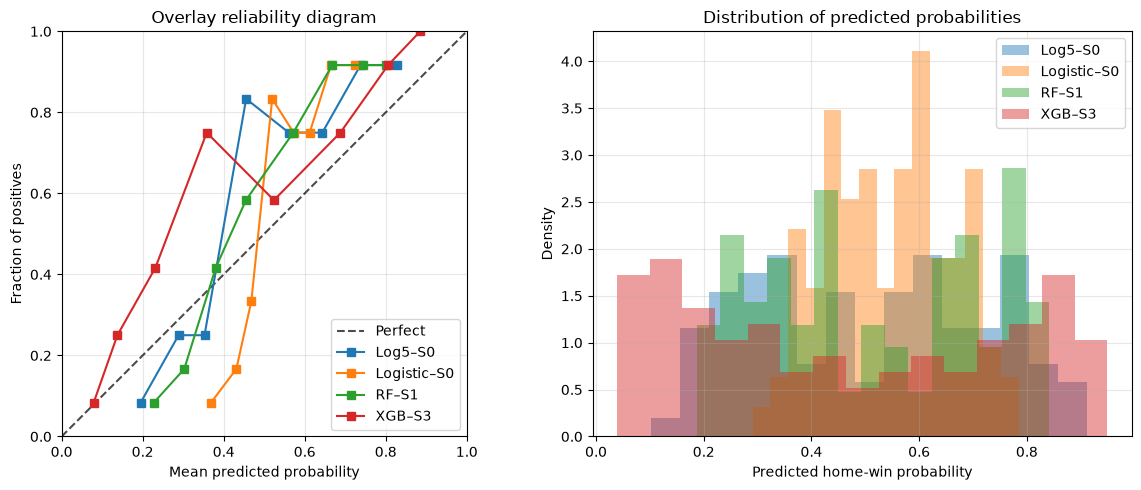

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overlay reliability
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", label="Perfect", alpha=0.7)
for key, label in FINALISTS.items():
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=label)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Overlay reliability diagram")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# Histograms of predicted probabilities
ax = axes[1]
for key, label in FINALISTS.items():
    p = fitted[key]["proba_ho"]
    ax.hist(p, bins=15, alpha=0.45, label=label, density=True)
ax.set_xlabel("Predicted home-win probability")
ax.set_ylabel("Density")
ax.set_title("Distribution of predicted probabilities")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Brier score decomposition (Murphy)

Brier = Reliability − Resolution + Uncertainty

- **Reliability** (lower better): how far the binned forecasts are from the observed frequencies  
- **Resolution** (higher better): how much the forecasts discriminate different event frequencies  
- **Uncertainty**: inherent variance of the binary outcome (same for all models on the same sample)


In [12]:
def brier_decomposition(y, p, n_bins=10, strategy="quantile"):
    y, p = np.asarray(y), np.asarray(p)
    if strategy == "quantile":
        bins = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    else:
        bins = np.linspace(0, 1, n_bins + 1)

    base_rate = y.mean()
    uncertainty = base_rate * (1 - base_rate)

    reliability = 0.0
    resolution = 0.0
    n = len(y)

    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask = (p >= lo) & (p < hi if i < len(bins) - 2 else p <= hi)
        nk = mask.sum()
        if nk == 0:
            continue
        pk = p[mask].mean()
        ok = y[mask].mean()
        reliability += (nk / n) * (pk - ok) ** 2
        resolution  += (nk / n) * (ok - base_rate) ** 2

    brier = reliability - resolution + uncertainty
    return {
        "brier": brier,
        "reliability": reliability,
        "resolution": resolution,
        "uncertainty": uncertainty,
    }

decomp_rows = []
for key, label in FINALISTS.items():
    d = brier_decomposition(fitted[key]["y_ho"], fitted[key]["proba_ho"])
    decomp_rows.append({"model": label, **d})

decomp_df = pd.DataFrame(decomp_rows).set_index("model")
print(decomp_df.round(5))
print()
print("Lower reliability + higher resolution → better probability forecasts")


               brier  reliability  resolution  uncertainty
model                                                     
Log5–S0      0.17231      0.02648     0.09538      0.24121
Logistic–S0  0.18997      0.05143     0.10267      0.24121
RF–S1        0.16582      0.03087     0.10626      0.24121
XGB–S3       0.18135      0.03100     0.09086      0.24121

Lower reliability + higher resolution → better probability forecasts


## 12. Observed win rate by predicted-probability tertile

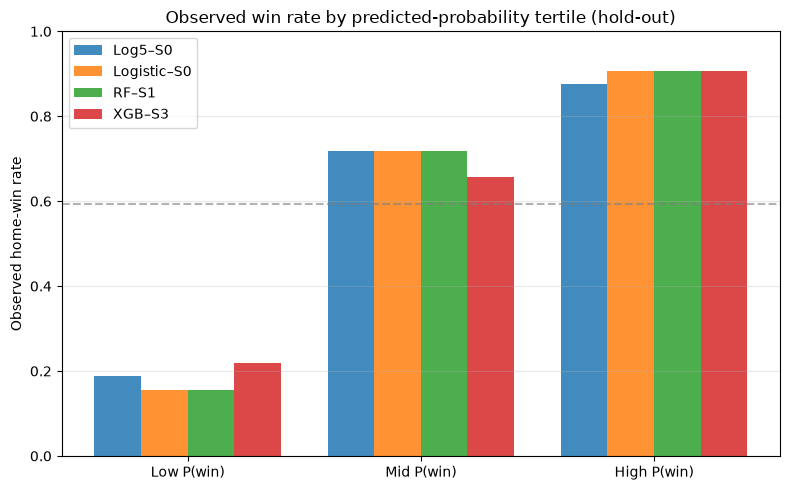

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
width = 0.2
colors = ["C0", "C1", "C2", "C3"]

for i, (key, label) in enumerate(FINALISTS.items()):
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    # tertiles of predicted probability
    qs = np.quantile(p, [0, 1/3, 2/3, 1])
    rates = []
    for j in range(3):
        mask = (p >= qs[j]) & (p <= qs[j+1] if j == 2 else p < qs[j+1])
        rates.append(y[mask].mean() if mask.any() else np.nan)
    ax.bar(x + i * width, rates, width, label=label, color=colors[i], alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(["Low P(win)", "Mid P(win)", "High P(win)"])
ax.set_ylabel("Observed home-win rate")
ax.set_title("Observed win rate by predicted-probability tertile (hold-out)")
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(hold["home_win"].mean(), color="gray", ls="--", alpha=0.6, label="overall base rate")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Bootstrap confidence intervals (hold-out)

In [14]:
def bootstrap_ci(y, p, metric_fn, n_boot=1000, alpha=0.05, rng=None):
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    y = np.asarray(y)
    p = np.asarray(p)
    n = len(y)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        stats.append(metric_fn(y[idx], p[idx]))
    stats = np.array(stats)
    return float(np.mean(stats)), float(np.percentile(stats, 100 * alpha / 2)), float(np.percentile(stats, 100 * (1 - alpha / 2)))

def brier(y, p):
    return brier_score_loss(y, np.clip(p, 1e-6, 1 - 1e-6))

def logloss_fn(y, p):
    return log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))

ci_rows = []
for key, label in FINALISTS.items():
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    b_mean, b_lo, b_hi = bootstrap_ci(y, p, brier)
    l_mean, l_lo, l_hi = bootstrap_ci(y, p, logloss_fn)
    ci_rows.append({
        "model": label,
        "brier": b_mean, "brier_lo": b_lo, "brier_hi": b_hi,
        "logloss": l_mean, "logloss_lo": l_lo, "logloss_hi": l_hi,
    })

ci_df = pd.DataFrame(ci_rows).set_index("model")
print(ci_df.round(4))


              brier  brier_lo  brier_hi  logloss  logloss_lo  logloss_hi
model                                                                   
Log5–S0      0.1702    0.1417    0.1992   0.5185      0.4558      0.5837
Logistic–S0  0.1893    0.1723    0.2065   0.5676      0.5323      0.6039
RF–S1        0.1665    0.1396    0.1921   0.5133      0.4551      0.5697
XGB–S3       0.1797    0.1407    0.2233   0.5370      0.4369      0.6483


## 14. Pairwise significance tests (bootstrap difference in Brier)

In [15]:
from itertools import combinations

def paired_bootstrap_diff(y, p1, p2, metric_fn, n_boot=1000, alpha=0.05):
    rng = np.random.default_rng(RANDOM_STATE)
    y, p1, p2 = map(np.asarray, (y, p1, p2))
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs.append(metric_fn(y[idx], p1[idx]) - metric_fn(y[idx], p2[idx]))
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    lo, hi = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    # two-sided p-value approximation
    p_val = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return mean_diff, lo, hi, p_val

print("Difference = Brier(A) - Brier(B)   (negative ⇒ A better)")
print()
keys = list(FINALISTS.keys())
for a, b in combinations(keys, 2):
    y = fitted[a]["y_ho"]  # same hold-out labels
    diff, lo, hi, p = paired_bootstrap_diff(
        y, fitted[a]["proba_ho"], fitted[b]["proba_ho"], brier
    )
    sig = "*" if p < 0.05 else ""
    print(f"{FINALISTS[a]:12s} vs {FINALISTS[b]:12s}  "
          f"ΔBrier={diff:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  p≈{p:.3f} {sig}")


Difference = Brier(A) - Brier(B)   (negative ⇒ A better)

Log5–S0      vs Logistic–S0   ΔBrier=-0.0191  95% CI [-0.0343, -0.0025]  p≈0.026 *
Log5–S0      vs RF–S1         ΔBrier=+0.0037  95% CI [-0.0093, +0.0171]  p≈0.614 
Log5–S0      vs XGB–S3        ΔBrier=-0.0095  95% CI [-0.0402, +0.0177]  p≈0.562 
Logistic–S0  vs RF–S1         ΔBrier=+0.0229  95% CI [+0.0072, +0.0381]  p≈0.012 *
Logistic–S0  vs XGB–S3        ΔBrier=+0.0097  95% CI [-0.0254, +0.0425]  p≈0.590 
RF–S1        vs XGB–S3        ΔBrier=-0.0132  95% CI [-0.0414, +0.0132]  p≈0.384 


## 15. Platt recalibration

Logistic (Platt) scaling is fit on *validation* predictions and applied to the hold-out set for the two tree-based finalists.


In [16]:
def platt_scale(p_val, y_val, p_ho):
    p_val = np.clip(p_val, 1e-6, 1 - 1e-6)
    logit_val = np.log(p_val / (1 - p_val)).reshape(-1, 1)
    lr = LR_cal(penalty=None, solver="lbfgs", max_iter=1000)
    lr.fit(logit_val, y_val)
    p_ho = np.clip(p_ho, 1e-6, 1 - 1e-6)
    logit_ho = np.log(p_ho / (1 - p_ho)).reshape(-1, 1)
    return lr.predict_proba(logit_ho)[:, 1]

print("Before / after Platt scaling on hold-out:\n")
for key in ["rf__S1", "xgboost__S3"]:
    label = FINALISTS[key]
    y_ho = fitted[key]["y_ho"]
    p_raw = fitted[key]["proba_ho"]
    p_cal = platt_scale(fitted[key]["proba_va"], fitted[key]["y_va"], p_raw)

    b_raw = brier_score_loss(y_ho, p_raw)
    b_cal = brier_score_loss(y_ho, p_cal)
    ece_raw, _ = expected_calibration_error(y_ho, p_raw)
    ece_cal, _ = expected_calibration_error(y_ho, p_cal)

    print(f"{label}")
    print(f"  Brier   raw={b_raw:.4f}  calibrated={b_cal:.4f}  (Δ={b_cal - b_raw:+.4f})")
    print(f"  ECE     raw={ece_raw:.4f}  calibrated={ece_cal:.4f}  (Δ={ece_cal - ece_raw:+.4f})")
    print()


Before / after Platt scaling on hold-out:

RF–S1
  Brier   raw=0.1661  calibrated=0.1475  (Δ=-0.0187)
  ECE     raw=0.1613  calibrated=0.0912  (Δ=-0.0701)

XGB–S3
  Brier   raw=0.1796  calibrated=0.1638  (Δ=-0.0158)
  ECE     raw=0.1301  calibrated=0.1015  (Δ=-0.0286)



## 16. Feature importance (S3)

In [17]:
s3_features = FEATURE_SETS["S3"]

# XGBoost gain
xgb_model = fitted["xgboost__S3"]["model"]
score = xgb_model.get_booster().get_score(importance_type="gain")
xgb_imp = {f: score.get(f, 0.0) for f in s3_features}

# RF
rf_model = fitted["rf__S3"]["model"] if "rf__S3" in fitted else fitted["rf__S1"]["model"]
# Note: RF was locked on S1; for S3 importance we re-fit quickly if needed
if "rf__S3" not in fitted:
    X_tr, y_tr = get_xy(train, s3_features)
    rf_s3 = MODELS["rf"]()
    rf_s3.fit(X_tr, y_tr)
    rf_imp = dict(zip(s3_features, rf_s3.feature_importances_))
else:
    rf_imp = dict(zip(s3_features, rf_model.feature_importances_))

# Logistic abs coef (on S3)
X_tr, y_tr = get_xy(train, s3_features)
logit = MODELS["logistic"]()
logit.fit(X_tr, y_tr)
# Pipeline → last step is the classifier
coef = np.abs(logit.named_steps["clf"].coef_[0])
log_imp = dict(zip(s3_features, coef))

imp_df = pd.DataFrame({
    "xgb_gain": pd.Series(xgb_imp),
    "rf_imp": pd.Series(rf_imp),
    "log_abs_coef": pd.Series(log_imp),
}).fillna(0)

# rank average
imp_df["rank_xgb"] = imp_df["xgb_gain"].rank(ascending=False)
imp_df["rank_rf"] = imp_df["rf_imp"].rank(ascending=False)
imp_df["rank_log"] = imp_df["log_abs_coef"].rank(ascending=False)
imp_df["avg_rank"] = imp_df[["rank_xgb", "rank_rf", "rank_log"]].mean(axis=1)
imp_df = imp_df.sort_values("avg_rank")

print(imp_df[["xgb_gain", "rf_imp", "log_abs_coef", "avg_rank"]].head(15).round(4))


                             xgb_gain  rf_imp  log_abs_coef  avg_rank
away_points_allowed_overall    3.4728  0.0648        0.7355    3.0000
home_points_allowed_overall    3.5114  0.0717        0.4035    3.3333
away_win_pct_overall           3.7451  0.0796        0.2384    4.0000
away_rebounds_net_on_road      3.4550  0.0482        0.4211    5.0000
home_points_allowed_at_home    2.9037  0.0684        0.2806    6.0000
home_win_pct_overall           2.7653  0.0753        0.1274    7.3333
away_rebounds_net_overall      2.6514  0.0322        0.4053    9.0000
home_points_overall            2.7568  0.0349        0.2832    9.3333
away_points_overall            2.4142  0.0388        0.4543    9.6667
away_points_on_road            2.6222  0.0538        0.1183   11.3333
home_win_pct_at_home           2.4072  0.0317        0.3863   13.0000
away_turnovers_net_on_road     2.6224  0.0303        0.1999   13.3333
games_played_sum               2.6276  0.0265        0.1991   13.6667
away_points_allowed_

## 17. Summary

Four finalists were selected by assigning each model its best feature regime:

| Finalist        | Regime | Role                            |
|-----------------|--------|---------------------------------|
| Log5            | S0     | Closed-form baseline            |
| Logistic        | S0     | Best linear model               |
| Random Forest   | S1     | Best overall probability model  |
| XGBoost         | S3     | Best boosted model              |

**Random Forest on S1** achieves the lowest Brier score and log-loss on the April hold-out.  
The two-feature Log5 baseline remains close behind, illustrating that a simple, well-calibrated model can stay competitive when only pre-game information is available.

Diagnostics included: ECE/MCE, calibration slopes, Brier decomposition (reliability / resolution), reliability diagrams, predicted-probability histograms, tertile calibration, bootstrap CIs, pairwise significance tests, and Platt recalibration.
